# 06. Model Clustering: Training - Pandas

## 06.1. Importação das bibliotecas

### 06.1.1. Importando as bibliotecas nativas do Python

In [1]:
import sys

### 06.1.2. Importando as bibliotecas de terceiros

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PowerTransformer, StandardScaler

### 06.1.3. Importando os módulos locais do projeto

In [3]:
sys.path.append('..')
import functions.fn_charts_pandas as fn_charts_pandas
import functions.fn_stats_pandas as fn_stats_pandas
import params.consts as consts

## 06.2. Visão geral dos dados

### 06.2.1. Habilitando a exibição de todas as colunas

In [4]:
pd.set_option('display.max_columns', None)

### 06.2.2. Armazenando o dataset em uma variável

In [5]:
df = pd.read_parquet(consts.DATASET_CLEAN_PANDAS)

### 06.2.3. Visualizando a quantidade de linhas e colunas do dataset

In [6]:
df.shape

(2205, 22)

### 06.2.4. Exibindo o dataset

In [7]:
df.head(5)

,Education,Marital_Status,Children,HasChildren,Age,AgeGroup,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Response
0,Graduation,Single,0,0,57,46-60,58138.0,58,0,9,3,663,1,3,7,22,1529,88,1617,0,0,1
1,Graduation,Single,2,1,60,46-60,46344.0,38,0,3,1,113,0,2,5,4,21,6,27,0,0,0
2,Graduation,Partner,0,0,49,46-60,71613.0,26,0,8,3,312,0,1,4,20,734,42,776,0,0,0
3,Graduation,Partner,1,1,30,18-30,26646.0,26,0,2,1,139,0,2,6,6,48,5,53,0,0,0
4,PhD,Partner,1,1,33,31-45,58293.0,94,0,1,1,161,0,5,5,14,407,15,422,0,0,0


### 06.2.5. Visualizando os detalhes do dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Education             2205 non-null   object  
 1   Marital_Status        2205 non-null   object  
 2   Children              2205 non-null   int64   
 3   HasChildren           2205 non-null   int64   
 4   Age                   2205 non-null   int64   
 5   AgeGroup              2205 non-null   category
 6   Income                2205 non-null   float64 
 7   Recency               2205 non-null   int64   
 8   Complain              2205 non-null   int64   
 9   Dt_Customer_Month     2205 non-null   int64   
 10  Dt_Customer_Quarter   2205 non-null   int64   
 11  Days_Since_Enrolled   2205 non-null   int64   
 12  Years_Since_Enrolled  2205 non-null   int64   
 13  NumDealsPurchases     2205 non-null   int64   
 14  NumWebVisitsMonth     2205 non-null   int64   
 15  NumT

### 06.2.6. Visualizando as estatísticas das colunas numéricas

In [9]:
fn_stats_pandas.describe(df)

,Children,HasChildren,Age,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Response
count,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00
mean,0.95,0.72,45.10,51622.09,49.01,0.01,6.47,2.48,353.72,0.48,2.32,5.34,12.57,562.76,44.06,606.82,0.30,0.21,0.15
std,0.75,0.45,11.71,20713.06,28.93,0.09,3.49,1.14,202.56,0.50,1.89,2.41,7.18,575.94,51.74,601.68,0.68,0.41,0.36
min,0.00,0.00,18.00,1730.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,4.00,0.00,5.00,0.00,0.00,0.00
25%,0.00,0.00,37.00,35196.00,24.00,0.00,3.00,1.00,180.00,0.00,1.00,3.00,6.00,56.00,9.00,69.00,0.00,0.00,0.00
50%,1.00,1.00,44.00,51287.00,49.00,0.00,6.00,2.00,356.00,0.00,2.00,6.00,12.00,343.00,25.00,397.00,0.00,0.00,0.00
75%,1.00,1.00,55.00,68281.00,74.00,0.00,10.00,4.00,529.00,1.00,3.00,7.00,18.00,964.00,56.00,1047.00,0.00,0.00,0.00
max,3.00,1.00,74.00,113734.00,99.00,1.00,12.00,4.00,699.00,1.00,15.00,20.00,32.00,2491.00,321.00,2525.00,4.00,1.00,1.00


### 06.2.7. Visualizando as estatísticas da colunas categóricas

In [10]:
df.describe(exclude = 'number')

,Education,Marital_Status,AgeGroup
count,2205,2205,2205
unique,5,2,4
top,Graduation,Partner,31-45
freq,1113,1422,958


### 06.2.8. Verificando os valores nulos das colunas

In [11]:
df.isnull().sum()

Education               0
Marital_Status          0
Children                0
HasChildren             0
Age                     0
AgeGroup                0
Income                  0
Recency                 0
Complain                0
Dt_Customer_Month       0
Dt_Customer_Quarter     0
Days_Since_Enrolled     0
Years_Since_Enrolled    0
NumDealsPurchases       0
NumWebVisitsMonth       0
NumTotalPurchases       0
MntRegularProds         0
MntGoldProds            0
MntTotal                0
AcceptedCmpTotal        0
HasAcceptedCmp          0
Response                0
dtype: int64

### 06.2.9. Verificando os valores distintos das colunas

In [12]:
df.nunique()

Education                  5
Marital_Status             2
Children                   4
HasChildren                2
Age                       56
AgeGroup                   4
Income                  1963
Recency                  100
Complain                   2
Dt_Customer_Month         12
Dt_Customer_Quarter        4
Days_Since_Enrolled      662
Years_Since_Enrolled       2
NumDealsPurchases         15
NumWebVisitsMonth         16
NumTotalPurchases         33
MntRegularProds          897
MntGoldProds             212
MntTotal                1045
AcceptedCmpTotal           5
HasAcceptedCmp             2
Response                   2
dtype: int64

### 06.2.10. Verificando os registos totalmente duplicados

In [13]:
len(df) - len(df.drop_duplicates())

185

### 06.2.11. Verificando a quantidade de colunas numéricas, categóricas e de data

In [14]:
num_cols = df.select_dtypes(include = 'number').shape[1]

categ_cols = df.select_dtypes(include = 'object').shape[1]

date_cols = df.select_dtypes(include = ['datetime64[ns]', 'datetime64[ns, UTC]']).shape[1]

print(f'- Numeric Columns: {num_cols}\n- Categoric Columns: {categ_cols}\n- Date Columns: {date_cols}')

- Numeric Columns: 19
- Categoric Columns: 2
- Date Columns: 0


## 06.3. Treinamento do modelo de clusterização

### 06.3.1. Listando as colunas numéricas e categóricas

In [15]:
numerical_features = df.select_dtypes(include = 'number').columns

print('Numerical Features:')

for i in numerical_features:

    print(f'- {i}')

Numerical Features:
- Children
- HasChildren
- Age
- Income
- Recency
- Complain
- Dt_Customer_Month
- Dt_Customer_Quarter
- Days_Since_Enrolled
- Years_Since_Enrolled
- NumDealsPurchases
- NumWebVisitsMonth
- NumTotalPurchases
- MntRegularProds
- MntGoldProds
- MntTotal
- AcceptedCmpTotal
- HasAcceptedCmp
- Response


In [16]:
categorical_features = df.select_dtypes(exclude = 'number').columns

print('\nCategorical Features:')

for i in categorical_features:
    
    print(f'- {i}')


Categorical Features:
- Education
- Marital_Status
- AgeGroup


### 06.3.2. Criando histogramas para entender a distribuição de dados das colunas

- Gráfico: Histograma.


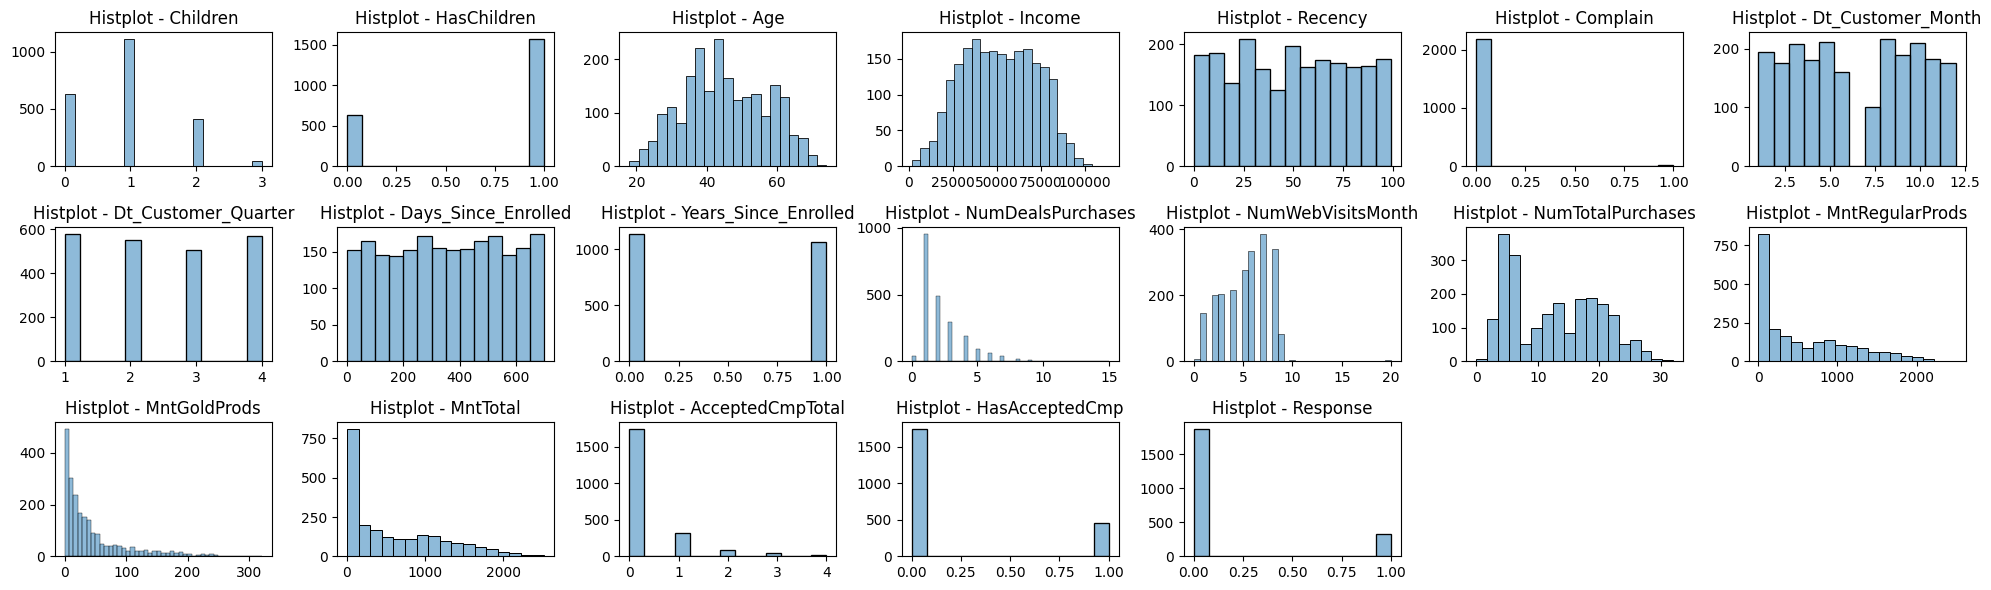

In [17]:
print('- Gráfico: Histograma.')

fn_charts_pandas.histplot(df, numerical_features, num_cols = 7, height_figsize = 2)

plt.savefig(f'../images/outputs/charts/pandas/nb06_histplot.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 06.3.3. Definindo o pré processamento das colunas de acordo com a distribuição dos seus dados

- **One Hot Encoder:** Indicado para colunas categóricas ou que possuem inteiros discretos.
- **Standard Scaler:** Indicado para colunas com distribuição semelhante à normal.
- **Power Transformer:** Indicado para colunas com assimetria dos dados.
- **Min-Max Scaler:** Indicado para colunas com distribuição uniforme dos dados.

In [18]:
one_hot_encoder_columns = [
    'Education',
    'Marital_Status',
    'AgeGroup',
    'Children',
    'HasChildren',
    'Complain',
    'Years_Since_Enrolled',
    'AcceptedCmpTotal',
    'HasAcceptedCmp',
    'Response',
]

standard_scaler_columns = [
    'Income',
    'Age',
]

power_transformer_columns = [
   'NumDealsPurchases',
   'NumWebVisitsMonth',
   'NumTotalPurchases',
   'MntRegularProds',
   'MntGoldProds',
   'MntTotal',
]

min_max_scaler_columns = [
    'Recency',
    'Dt_Customer_Month',
    'Dt_Customer_Quarter',
    'Days_Since_Enrolled',
]

### 06.3.4. Criando um dataset com o resultado do pré processamento

In [19]:
pre_processing = ColumnTransformer([

        ('one_hot_encoder', OneHotEncoder(), one_hot_encoder_columns),

        ('standard_scaler', StandardScaler(), standard_scaler_columns),

        ('power_transformer', PowerTransformer(), power_transformer_columns),

        ('min_max_scaler', MinMaxScaler(), min_max_scaler_columns)
    
])

df_transformed = pd.DataFrame(

    pre_processing.fit_transform(df),

    columns = pre_processing.get_feature_names_out()

)

df_transformed.head(3)

,one_hot_encoder__Education_2n Cycle,one_hot_encoder__Education_Basic,one_hot_encoder__Education_Graduation,one_hot_encoder__Education_Master,one_hot_encoder__Education_PhD,one_hot_encoder__Marital_Status_Partner,one_hot_encoder__Marital_Status_Single,one_hot_encoder__AgeGroup_18-30,one_hot_encoder__AgeGroup_31-45,one_hot_encoder__AgeGroup_46-60,one_hot_encoder__AgeGroup_61+,one_hot_encoder__Children_0,one_hot_encoder__Children_1,one_hot_encoder__Children_2,one_hot_encoder__Children_3,one_hot_encoder__HasChildren_0,one_hot_encoder__HasChildren_1,one_hot_encoder__Complain_0,one_hot_encoder__Complain_1,one_hot_encoder__Years_Since_Enrolled_0,one_hot_encoder__Years_Since_Enrolled_1,one_hot_encoder__AcceptedCmpTotal_0,one_hot_encoder__AcceptedCmpTotal_1,one_hot_encoder__AcceptedCmpTotal_2,one_hot_encoder__AcceptedCmpTotal_3,one_hot_encoder__AcceptedCmpTotal_4,one_hot_encoder__HasAcceptedCmp_0,one_hot_encoder__HasAcceptedCmp_1,one_hot_encoder__Response_0,one_hot_encoder__Response_1,standard_scaler__Income,standard_scaler__Age,power_transformer__NumDealsPurchases,power_transformer__NumWebVisitsMonth,power_transformer__NumTotalPurchases,power_transformer__MntRegularProds,power_transformer__MntGoldProds,power_transformer__MntTotal,min_max_scaler__Recency,min_max_scaler__Dt_Customer_Month,min_max_scaler__Dt_Customer_Quarter,min_max_scaler__Days_Since_Enrolled
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.314651,1.017189,0.753752,0.700269,1.221174,1.310705,1.089046,1.315543,0.585859,0.727273,0.666667,0.948498
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.254877,1.273530,0.160834,-0.108417,-1.319438,-1.453924,-0.947497,-1.447153,0.383838,0.181818,0.000000,0.161660
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.965354,0.333612,-0.838557,-0.527390,1.025388,0.687964,0.442997,0.658507,0.262626,0.636364,0.666667,0.446352


### 06.3.5. Criando os gráficos dos métodos do cotovelo e da silhueta

- Gráfico: Gráfico de Linha - Método do Cotovelo e Método da Silhueta.


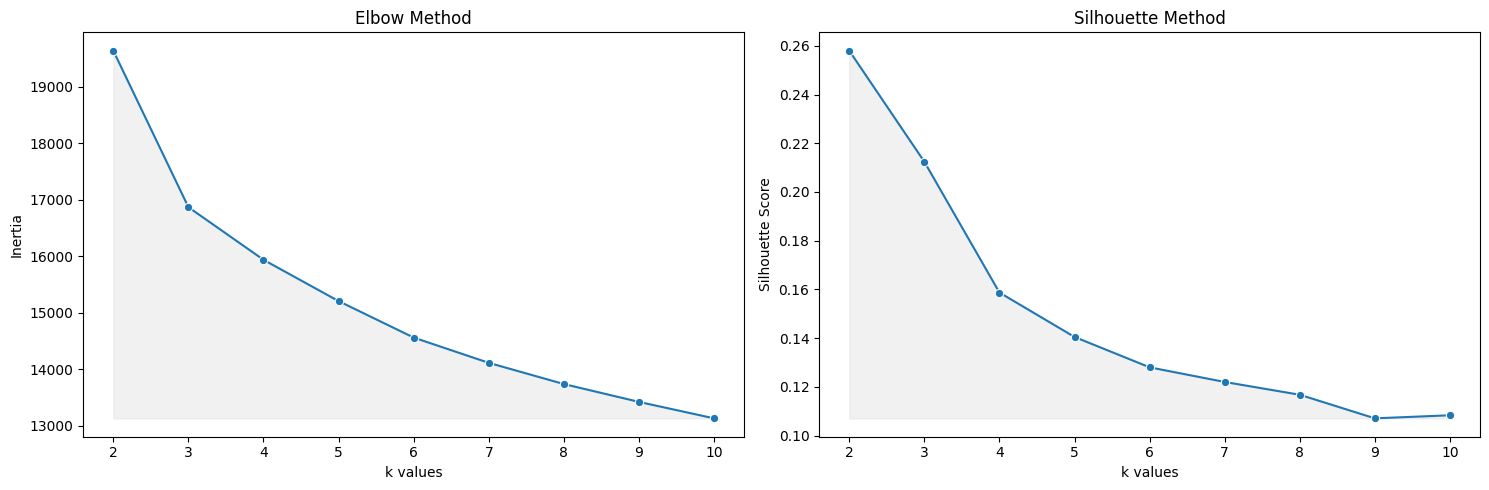

In [20]:
elbow = {}

silhouette = []

k_values = range(2, 11)

for i in k_values:

    kmeans = KMeans(n_clusters = i, random_state = consts.RANDOM_STATE, n_init = 10).fit(df_transformed)

    elbow[i] = kmeans.inertia_

    silhouette.append(silhouette_score(df_transformed, kmeans.labels_))

print('- Gráfico: Gráfico de Linha - Método do Cotovelo e Método da Silhueta.')

fn_charts_pandas.lineplot_elbow_silhouette(elbow, silhouette, k_values)

plt.savefig(f'../images/outputs/charts/pandas/nb06_lineplot_elbow_silhouette.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 06.3.6. Interpretando os resultados do método do cotovelo e do método da silhueta

- **Método do cotovelo:** Nesse gráfico, é possível perceber o "cotovelo" na posição 3, onde claramente há uma mudança de direção na plotagem do gráfico.
- **Método da silhueta:** Nesse gráfico, é possível identificar os maiores valores nas posições 2, 3 e 4, onde dessa forma representam os melhores valores a serem usados para identificação dos grupos.

**Conclusão:** Apesar de 2 ser o maior valor no gráfico do método da silhueta, não é tão interessante assim separar os clientes em apenas 2 grupos, o que muitas das vezes pode ser feito através de clientes de alta e baixa renda. Portanto, corroborando o valor identificado no gráfico do método do cotovelo, com o valor do "cotovelo" identificado na posição 3, esse valor de 3 grupos acaba sendo o ideal nesse contexto para a segmentação dos clientes.

### 06.3.7. Criando o pipeline

In [21]:
pipeline = Pipeline([

        ('pre_processing', pre_processing),

        ('dimensionality_reduction', PCA(n_components = 2, random_state = consts.RANDOM_STATE)),

        ('models', KMeans(n_clusters = 3, random_state = consts.RANDOM_STATE, n_init = 10))

])

### 06.3.8. Treinando o modelo

In [22]:
pipeline.fit(df)

Pipeline(steps=[('pre_processing',
                 ColumnTransformer(transformers=[('one_hot_encoder',
                                                  OneHotEncoder(),
                                                  ['Education',
                                                   'Marital_Status', 'AgeGroup',
                                                   'Children', 'HasChildren',
                                                   'Complain',
                                                   'Years_Since_Enrolled',
                                                   'AcceptedCmpTotal',
                                                   'HasAcceptedCmp',
                                                   'Response']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['Income', 'Age']),
                                                 ('power_transformer',
                                                  PowerTransformer(),
                                                  ['NumDealsPurchases',
                                                   'NumWebVisitsMonth',
                                                   'NumTotalPurchases',
                                                   'MntRegularProds',
                                                   'MntGoldProds',
                                                   'MntTotal']),
                                                 ('min_max_scaler',
                                                  MinMaxScaler(),
                                                  ['Recency',
                                                   'Dt_Customer_Month',
                                                   'Dt_Customer_Quarter',
                                                   'Days_Since_Enrolled'])])),
                ('dimensionality_reduction',
                 PCA(n_components=2, random_state=42)),
                ('models', KMeans(n_clusters=3, n_init=10, random_state=42))])

### 06.3.9. Evitando overfitting do modelo

- **Elbow e Silhouette Method:** Foram analisados os resultados dos gráficos de Elbow e Silhouette Method para se encontrar um número ótimo de clusters, não sendo um número nem tão baixo e nem tão alto de clusters. Além disso, os resultados de ambos os gráficos corroboraram a interpretação do outro.

## 06.4. Exportação dos dados

### 06.4.1. Criando o dataset clusterizado

In [23]:
df_clustered = df.copy()

df_clustered['Cluster'] = pipeline['models'].labels_

df_clustered.head()

,Education,Marital_Status,Children,HasChildren,Age,AgeGroup,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Response,Cluster
0,Graduation,Single,0,0,57,46-60,58138.0,58,0,9,3,663,1,3,7,22,1529,88,1617,0,0,1,2
1,Graduation,Single,2,1,60,46-60,46344.0,38,0,3,1,113,0,2,5,4,21,6,27,0,0,0,1
2,Graduation,Partner,0,0,49,46-60,71613.0,26,0,8,3,312,0,1,4,20,734,42,776,0,0,0,0
3,Graduation,Partner,1,1,30,18-30,26646.0,26,0,2,1,139,0,2,6,6,48,5,53,0,0,0,1
4,PhD,Partner,1,1,33,31-45,58293.0,94,0,1,1,161,0,5,5,14,407,15,422,0,0,0,2


### 06.4.2. Visualizando a segmentação dos clientes entre os clusters

- Agrupamento da coluna: Cluster


Cluster,Percentage,Count
0,24.9,550
1,41.3,910
2,33.8,745


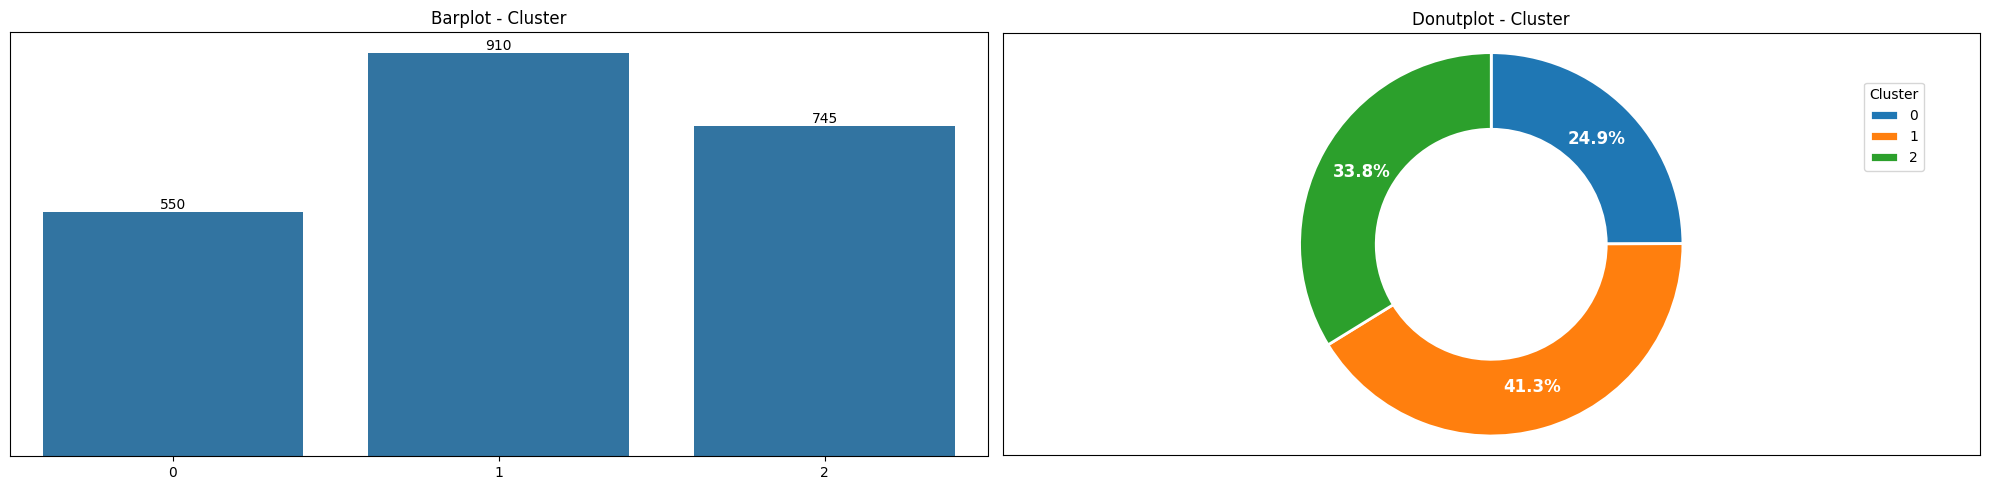

In [24]:
df_agg = fn_stats_pandas.groupby_count(df_clustered, 'Cluster')

print(f'- Agrupamento da coluna: Cluster')

display(HTML(df_agg.to_html(index = False)))

fn_charts_pandas.barplot_donutplot(df_agg, 'Cluster', 'Count')

plt.savefig(f'../images/outputs/charts/pandas/nb06_barplot_donutplot_cluster.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 06.4.3. Salvando o dataset clusterizado em parquet e compactado em snappy

In [25]:
df_clustered.to_parquet(

    consts.DATASET_CLUSTERED_PANDAS,

    index = False,

    compression = 'snappy'
    
)

## 06.5. Análise exploratória dos dados

### 06.5.1. Criando um gráfico de dispersão por PCA para visualizar a segmentação dos grupos após a clusterização

- Gráfico: Gráfico de Dispersão.


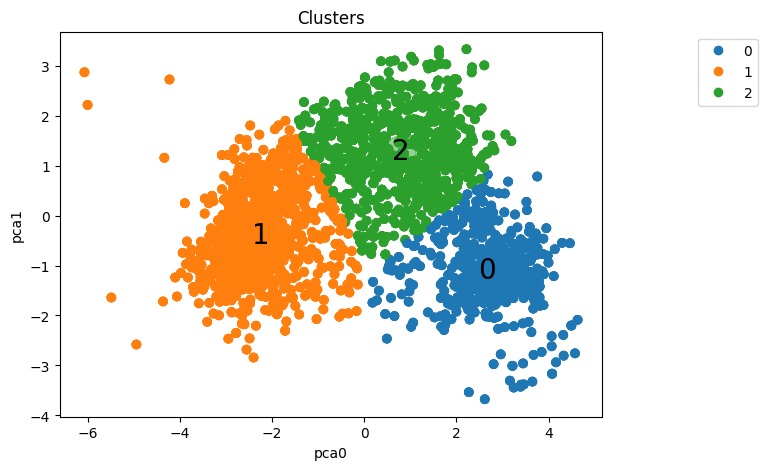

In [26]:
print('- Gráfico: Gráfico de Dispersão.')

df_pca = pd.DataFrame(pipeline[:-1].fit_transform(df), columns = pipeline[:-1].get_feature_names_out())

fn_charts_pandas.scatterplot_clusters_2D(df_pca, df_pca.columns, 3, pipeline['models'].cluster_centers_, column_clusters = df_clustered['Cluster'])

plt.savefig(f'../images/outputs/charts/pandas/nb06_scatterplot_clusters_2d.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 06.5.2. Criando um gráfico de dispersão de acordo com os clusters para entender a distribuição dos dados nesse cenário

- Gráfico: Gráfico de Dispersão.

- Scatter Column: Income.

- Hue Column: Cluster.


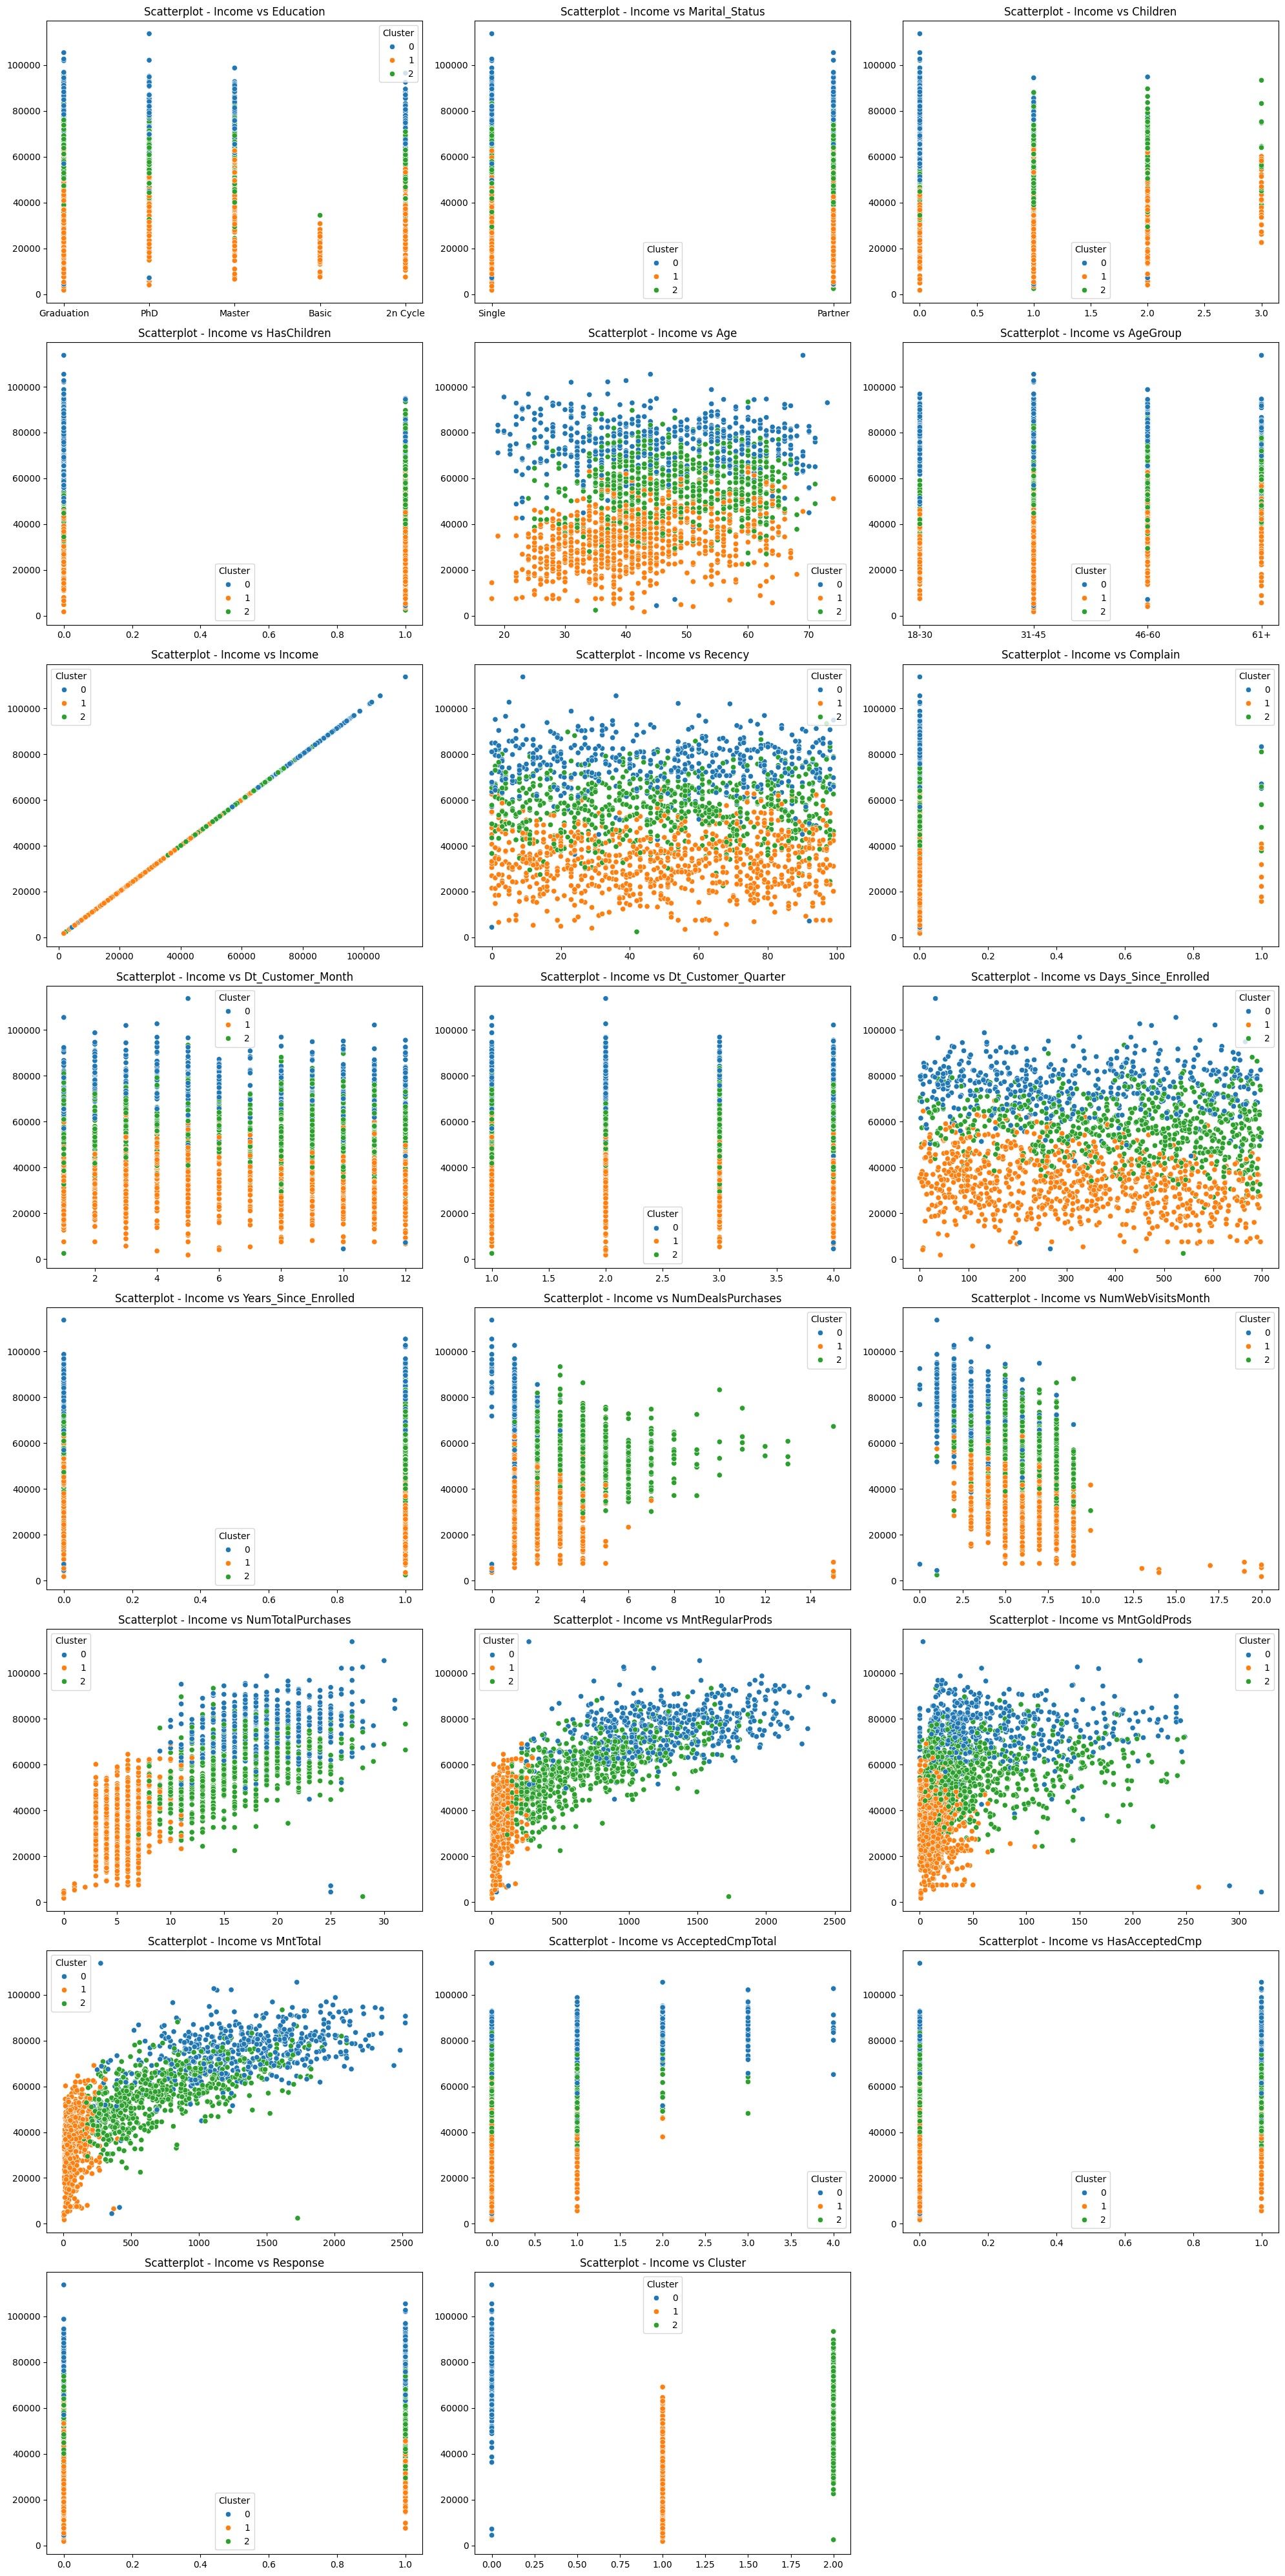

In [27]:
print('- Gráfico: Gráfico de Dispersão.\n')

print(f'- Scatter Column: Income.\n')

print(f'- Hue Column: Cluster.')

fn_charts_pandas.scatterplot(df_clustered, df_clustered.columns, 'Income', 'Cluster')

plt.savefig(f'../images/outputs/charts/pandas/nb06_scatterplot_income.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 06.5.3. Criando histogramas de acordo com os clusters para extrair insights

- Gráfico: Histograma.


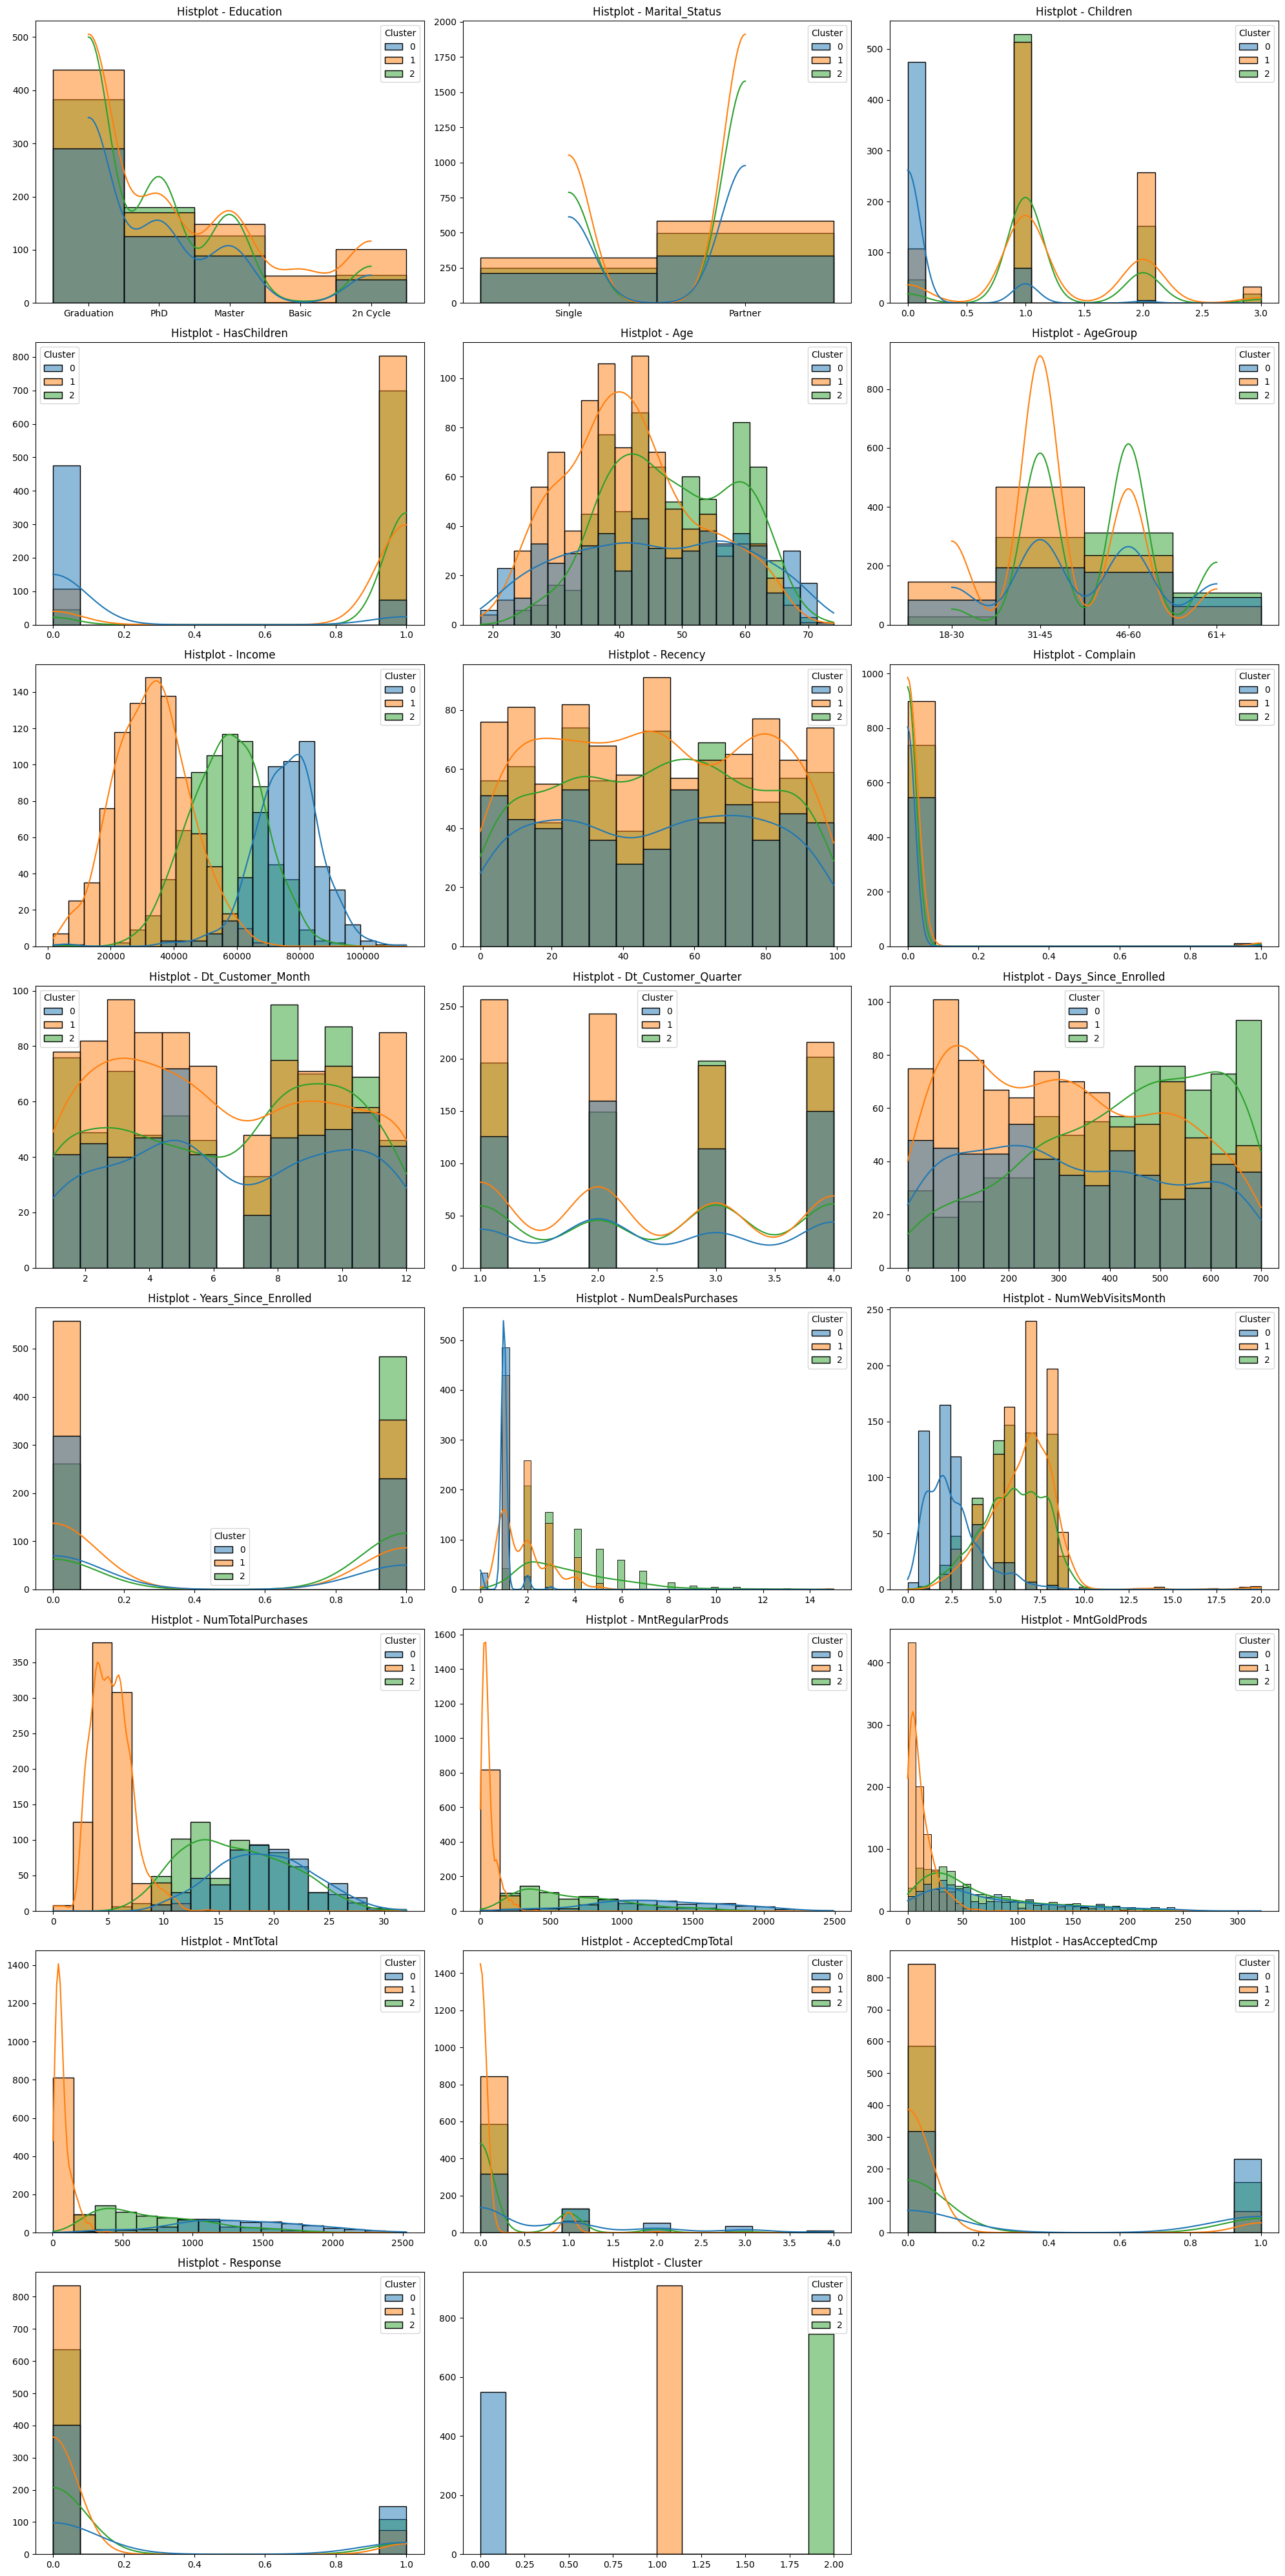

In [28]:
print('- Gráfico: Histograma.')

fn_charts_pandas.histplot(df_clustered, df_clustered.columns, 'Cluster', kde = True)

plt.savefig(f'../images/outputs/charts/pandas/nb06_histplot_cluster.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 06.5.4. Criando diagramas de caixa de acordo com os clusters para corroborar os insights encontrados nos histogramas

- Gráfico: Diagrama de Caixa.


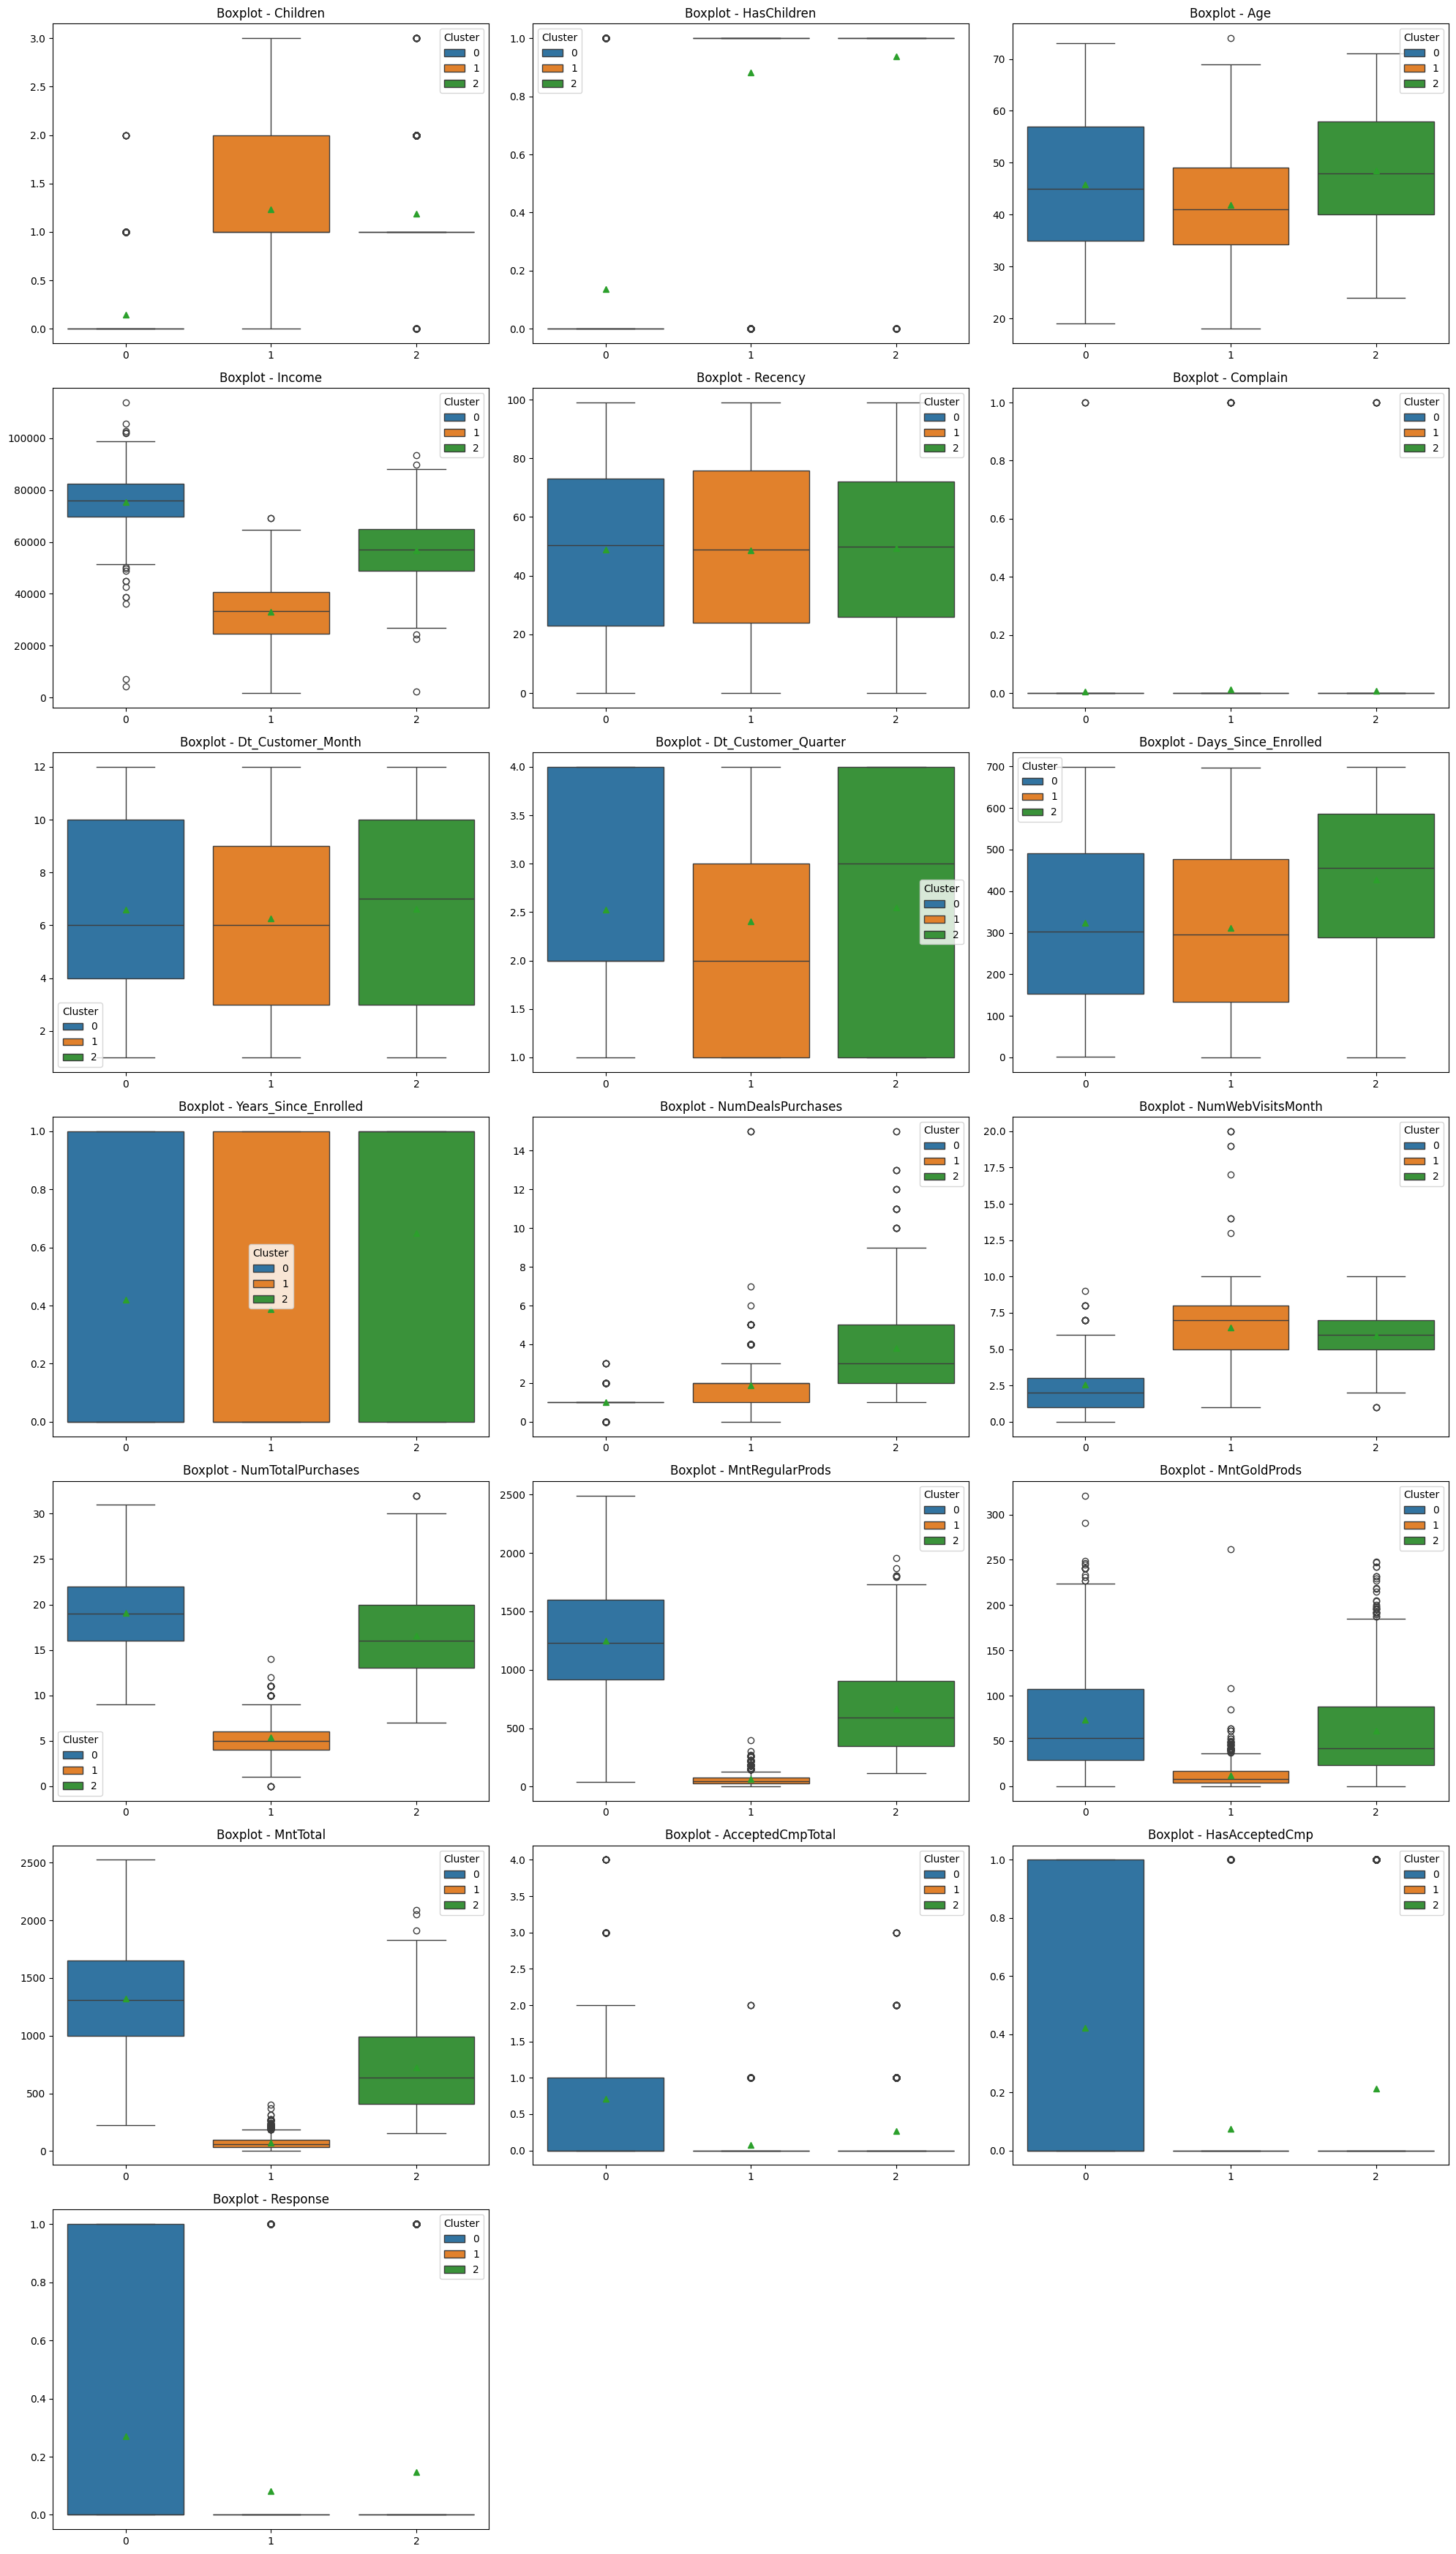

In [29]:
print('- Gráfico: Diagrama de Caixa.')

fn_charts_pandas.boxplot(df_clustered, df.select_dtypes(include = 'number').columns, 'Cluster', 'Cluster')

plt.savefig(f'../images/outputs/charts/pandas/nb06_boxplot_cluster.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 06.5.5. Identificando os grupos após a clusterização

| Cluster 0                          | Cluster 1                                          | Cluster 2                         |
|------------------------------------|----------------------------------------------------|-----------------------------------|
| Renda alta                         | Renda baixa                                        | Renda média                       |
| Faz muitas compras                 | Faz poucas compras                                 | Faz muitas compras                |
| Gasta muito em compras             | Gasta pouco em compras                             | Gasta moderadamente em compras    |
| Provavelmente não tem filhos       | Provavelmente tem filhos                           | Provavelmente tem filhos          |
| Faz poucas compras com desconto    | Faz algumas compras com desconto                   | Faz muitas compras com desconto   |
| Visita pouco o site                | Visita muito o site                                | Visita muito o site               |
| Alta escolaridade                  | Único grupo que tem pessoas com escolaridade baixa | Alta escolaridade                 |
| **Aceita campanhas facilmente**    | **Dificilmente aceita campanhas**                  | **Pode aceitar campanhas**        |
| É cliente há menos tempo           | É cliente há menos tempo                           | É cliente há mais tempo           |